# CatBoost + Text OOF Feature v1

Bu notebook sıfırdan oluşturulmuş deney notebook'udur.

Ana fikir:
- `mentor_feedback_text` doğrudan CatBoost'a verilmez.
- Text için ayrı bir TF-IDF + Ridge modeli kurulur.
- Bu text modelinin OOF tahmini `text_model_pred` olarak CatBoost'a numeric feature şeklinde eklenir.
- Elle ağır katsayılı feature'lar azaltılır.
- CatBoost native categorical kullanılır.
- Submission `results/catboost_text_oof_feature_v1_submission.csv` olarak kaydedilir.

Dosya yolları bilinçli olarak değiştirilmedi:

```python
TRAIN_PATH = "train.csv"
TEST_PATH = "test_x.csv"
```


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy import sparse

from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

TRAIN_PATH = "data/train.csv"
TEST_PATH = "data/test_x.csv"

TARGET = "career_success_score"
ID_COL = "student_id"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

RUN_NAME = "catboost_text_oof_feature_v1"


In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

assert TARGET in train_df.columns, f"{TARGET} train içinde yok."
assert ID_COL in train_df.columns, f"{ID_COL} train içinde yok."
assert ID_COL in test_df.columns, f"{ID_COL} test içinde yok."

print("Target min/max:", train_df[TARGET].min(), train_df[TARGET].max())
display(train_df.head())
display(test_df.head())


Train shape: (10000, 47)
Test shape : (10000, 46)
Target min/max: 0.0 100.0


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,69.49,85.751415,72.860000,73.680000,54.080000,54.93,0,1,9.0,0,1,0,82.40,4,2.96,3.0,45.15,24.12,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,running,Reddit,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,74.11,80.620000,86.830000,80.340000,87.560000,72.85,2,0,NaN,2,0,0,48.02,14,0.97,12.0,74.86,74.83,71.82,65.14,63.30,52.86,27.22,84.29,1,0,119,13,football,X,92.46,Ürün analizi alanına olan tutkusu ve makine öğ...


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text
0,STU_010001,2025,23,2025,Computer Engineering,Tier 4,2.59,45.27,79.11,2,Frontend Developer,42.60,61.53,61.17,34.780000,39.570000,59.61,39.143557,43.540000,52.800000,40.83,1,2,14.0,1,0,0,92.14,8,NaN,NaN,15.41,52.16,62.90,41.79,51.08,90.02,81.33,30.54,6,2,46,6,gaming,YouTube,Öğrencinin proje çalışmasında dikkat çekici bi...
1,STU_010002,2023,23,2022,Electrical Electronics Engineering,Tier 3,3.12,66.30,70.58,1,DevOps Engineer,71.63,95.42,81.59,78.360000,79.410000,74.65,60.360000,84.594122,66.284347,31.24,1,1,5.0,1,2,0,40.16,7,3.64,0.0,43.73,67.56,43.15,83.47,38.26,82.78,82.78,42.37,1,0,4,0,football,TikTok,"Bu öğrenci, problem çözme ve veri yapıları kon..."
2,STU_010003,2025,20,2025,Computer Engineering,Tier 3,3.48,75.45,67.93,0,Data Scientist,66.04,62.71,67.52,89.176084,58.108534,78.01,69.610000,66.840000,54.060000,26.53,1,1,2.0,3,0,0,59.12,8,NaN,NaN,14.96,68.73,71.74,64.96,88.49,51.79,63.30,66.01,4,1,66,3,cinema,Instagram,Öğrencinin veri bilimi konusundaki ilgisi ve g...
3,STU_010004,2020,26,2019,Software Engineering,Tier 2,2.92,45.58,83.95,0,Data Analyst,91.53,67.55,75.47,66.948792,62.822398,66.92,94.010000,64.990000,61.700000,82.96,1,0,0.0,0,1,0,73.90,9,3.18,3.0,NaN,52.79,84.60,79.40,76.32,90.89,46.64,82.60,3,2,42,2,chess,LinkedIn,Son derece etkileyici bir başarıya imza atan b...
4,STU_010005,2024,21,2024,Computer Engineering,Tier 3,2.85,63.08,84.18,1,Software Developer,70.82,70.65,65.16,62.290000,70.590000,54.44,80.420000,41.970000,63.230000,79.70,2,1,6.0,1,1,0,79.54,6,2.04,6.0,58.00,33.37,33.40,77.29,48.09,42.78,43.30,39.65,3,1,25,0,reading,TikTok,Öğrencinin yazılım geliştirme alanındaki çalış...


In [5]:
print("Train missing values:")
display(train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False))

print("\nTest missing values:")
display(test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False))


Train missing values:


internship_duration_months        1657
english_exam_score                 953
github_avg_stars                   910
open_source_contribution_count     910
hr_interview_score                 780
linkedin_profile_score             668
portfolio_score                    364
dtype: int64


Test missing values:


internship_duration_months        1586
english_exam_score                 944
github_avg_stars                   895
open_source_contribution_count     895
hr_interview_score                 759
linkedin_profile_score             680
portfolio_score                    382
dtype: int64

In [6]:
print("Train application_year distribution:")
display(train_df["application_year"].value_counts(normalize=True).sort_index())

print("Test application_year distribution:")
display(test_df["application_year"].value_counts(normalize=True).sort_index())

year_dist = pd.DataFrame({
    "train_ratio": train_df["application_year"].value_counts(normalize=True).sort_index(),
    "test_ratio": test_df["application_year"].value_counts(normalize=True).sort_index()
})
year_dist["test_train_ratio"] = year_dist["test_ratio"] / year_dist["train_ratio"]
display(year_dist)


Train application_year distribution:


application_year
2019    0.1289
2020    0.1329
2021    0.1270
2022    0.1293
2023    0.1312
2024    0.1319
2025    0.1191
2026    0.0997
Name: proportion, dtype: float64

Test application_year distribution:


application_year
2019    0.0403
2020    0.0507
2021    0.0691
2022    0.0881
2023    0.1298
2024    0.1994
2025    0.2197
2026    0.2029
Name: proportion, dtype: float64

,train_ratio,test_ratio,test_train_ratio
application_year,,,
2019,0.1289,0.0403,0.312645
2020,0.1329,0.0507,0.381490
2021,0.1270,0.0691,0.544094
2022,0.1293,0.0881,0.681361
2023,0.1312,0.1298,0.989329
2024,0.1319,0.1994,1.511751
2025,0.1191,0.2197,1.844668
2026,0.0997,0.2029,2.035105


## Missing value işlemleri

Mantık:
- Missing flag'ler önce oluşturulur.
- Fill değerleri train üzerinden öğrenilir.
- Test'e train'den öğrenilen mean/median/grup median uygulanır.


In [7]:
def add_missing_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    missing_cols = [
        "english_exam_score",
        "internship_duration_months",
        "portfolio_score",
        "github_avg_stars",
        "open_source_contribution_count",
        "linkedin_profile_score",
        "hr_interview_score"
    ]

    for col in missing_cols:
        if col in df.columns:
            df[f"{col}_was_missing"] = df[col].isna().astype(int)

    return df


def fill_missing_values(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    mean_cols = [
        "english_exam_score",
        "linkedin_profile_score",
        "hr_interview_score",
        "portfolio_score"
    ]

    median_cols = [
        "github_avg_stars",
        "open_source_contribution_count"
    ]

    for col in mean_cols:
        if col in train.columns:
            fill_value = train[col].mean()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    for col in median_cols:
        if col in train.columns:
            fill_value = train[col].median()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    # internship_duration_months: internship_count grubuna göre train median
    col = "internship_duration_months"
    group_col = "internship_count"

    if col in train.columns and group_col in train.columns:
        global_median = train[col].median()
        group_medians = train.groupby(group_col)[col].median()

        train[col] = train.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        test[col] = test.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        train[col] = train[col].fillna(global_median)
        test[col] = test[col].fillna(global_median)

    if "mentor_feedback_text" in train.columns:
        train["mentor_feedback_text"] = train["mentor_feedback_text"].fillna("")
        test["mentor_feedback_text"] = test["mentor_feedback_text"].fillna("")

    return train, test


## Balanced numeric feature engineering

Bu sürümde ağır elle katsayılandırılmış feature'lar yerine daha kontrollü sinyaller kullanılır:

- Ortalama / std / range
- Rol uyum skoru
- Log dönüşümleri
- Oranlar
- `/100` ile ölçeklenmiş interaction'lar


In [8]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ------------------------------------------------------------
    # Graduation / temporal
    # ------------------------------------------------------------
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]

    # university_tier kategorik olarak kalır; ayrıca ordinal rank da eklenir.
    tier_rank_map = {
        "Tier 1": 4,
        "Tier 2": 3,
        "Tier 3": 2,
        "Tier 4": 1
    }
    if "university_tier" in df.columns:
        df["university_tier_rank"] = (
            df["university_tier"].map(tier_rank_map).fillna(0).astype(int)
        )

    # ------------------------------------------------------------
    # Technical skill summaries
    # ------------------------------------------------------------
    technical_skill_cols = [
        "coding_score",
        "problem_solving_score",
        "data_structures_score",
        "sql_score",
        "machine_learning_score",
        "backend_score",
        "frontend_score",
        "cloud_score",
        "devops_score"
    ]

    df["technical_skill_mean"] = df[technical_skill_cols].mean(axis=1)
    df["technical_skill_std"] = df[technical_skill_cols].std(axis=1)
    df["technical_skill_min"] = df[technical_skill_cols].min(axis=1)
    df["technical_skill_max"] = df[technical_skill_cols].max(axis=1)
    df["technical_skill_range"] = (
        df["technical_skill_max"] - df["technical_skill_min"]
    )

    df["data_ai_score"] = df[
        [
            "sql_score",
            "machine_learning_score",
            "problem_solving_score",
            "data_structures_score",
            "coding_score"
        ]
    ].mean(axis=1)

    df["software_engineering_score"] = df[
        [
            "backend_score",
            "frontend_score",
            "cloud_score",
            "devops_score",
            "coding_score",
            "data_structures_score"
        ]
    ].mean(axis=1)

    df["cloud_devops_score"] = df[
        ["cloud_score", "devops_score", "backend_score"]
    ].mean(axis=1)

    df["core_cs_score"] = df[
        ["coding_score", "problem_solving_score", "data_structures_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Role-specific skill fit
    # ------------------------------------------------------------
    role = df["target_role"].fillna("").astype(str).str.lower()

    df["role_skill_fit_score"] = df["technical_skill_mean"]

    role_score_specs = [
        (role.eq("backend developer"), ["backend_score", "coding_score", "data_structures_score", "problem_solving_score"]),
        (role.eq("frontend developer"), ["frontend_score", "coding_score", "presentation_score"]),
        (role.eq("software developer"), ["coding_score", "data_structures_score", "problem_solving_score", "backend_score", "frontend_score"]),
        (role.eq("data scientist"), ["machine_learning_score", "sql_score", "problem_solving_score", "data_structures_score", "coding_score"]),
        (role.eq("data analyst"), ["sql_score", "problem_solving_score", "machine_learning_score", "presentation_score"]),
        (role.eq("ai engineer"), ["machine_learning_score", "coding_score", "problem_solving_score", "data_structures_score", "cloud_score"]),
        (role.eq("mlops engineer"), ["machine_learning_score", "devops_score", "cloud_score", "coding_score"]),
        (role.eq("cloud engineer"), ["cloud_score", "devops_score", "backend_score"]),
        (role.eq("devops engineer"), ["devops_score", "cloud_score", "backend_score"]),
        (role.eq("cybersecurity analyst"), ["problem_solving_score", "backend_score", "devops_score", "cloud_score"]),
        (role.eq("product analyst"), ["sql_score", "presentation_score", "communication_score", "problem_solving_score"]),
    ]

    for mask, cols in role_score_specs:
        df.loc[mask, "role_skill_fit_score"] = df.loc[mask, cols].mean(axis=1)

    df["role_fit_minus_technical_mean"] = (
        df["role_skill_fit_score"] - df["technical_skill_mean"]
    )

    # ------------------------------------------------------------
    # Soft skills
    # ------------------------------------------------------------
    soft_skill_cols = [
        "communication_score",
        "teamwork_score",
        "leadership_score",
        "presentation_score",
        "linkedin_profile_score",
        "cv_quality_score",
        "hr_interview_score"
    ]

    df["soft_skill_mean"] = df[soft_skill_cols].mean(axis=1)
    df["soft_skill_std"] = df[soft_skill_cols].std(axis=1)
    df["communication_presentation_mean"] = df[
        ["communication_score", "presentation_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Project / portfolio / GitHub
    # ------------------------------------------------------------
    df["project_count_total"] = (
        df["real_client_project_count"] + df["freelance_project_count"]
    )

    df["portfolio_project_quality_mean"] = df[
        ["portfolio_score", "project_quality_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_project_quality_interaction"] = (
        df["portfolio_score"] * df["project_quality_score"] / 100
    )

    df["project_quality_x_real_client_log"] = (
        df["project_quality_score"] * np.log1p(df["real_client_project_count"])
    )

    df["project_quality_x_project_count_log"] = (
        df["project_quality_score"] * np.log1p(df["project_count_total"])
    )

    df["github_activity_log"] = np.log1p(
        df["github_repo_count"] * df["github_avg_stars"]
    )

    df["github_impact_log"] = (
        np.log1p(df["github_repo_count"])
        + np.log1p(df["github_avg_stars"])
        + np.log1p(df["open_source_contribution_count"])
    )

    df["github_per_repo_quality"] = (
        df["github_avg_stars"] / (df["github_repo_count"] + 1)
    )

    df["github_open_source_intensity"] = (
        df["open_source_contribution_count"] / (df["github_repo_count"] + 1)
    )

    df["profile_visibility_mean"] = df[
        ["linkedin_profile_score", "portfolio_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_x_linkedin"] = (
        df["portfolio_score"] * df["linkedin_profile_score"] / 100
    )

    # ------------------------------------------------------------
    # Experience / hackathon / learning
    # ------------------------------------------------------------
    df["experience_count_total"] = (
        df["real_client_project_count"]
        + df["internship_count"]
        + df["freelance_project_count"]
        + df["hackathon_count"]
        + df["certification_count"]
        + df["bootcamp_count"]
    )

    df["experience_count_log"] = np.log1p(df["experience_count_total"])

    df["internship_months_per_internship"] = (
        df["internship_duration_months"] / (df["internship_count"] + 1)
    )

    df["internship_experience_log"] = (
        np.log1p(df["internship_count"])
        + np.log1p(df["internship_duration_months"])
    )

    df["hackathon_award_rate"] = (
        df["hackathon_awards"] / (df["hackathon_count"] + 1)
    )

    df["hackathon_activity_log"] = (
        np.log1p(df["hackathon_count"]) + np.log1p(df["hackathon_awards"])
    )

    df["learning_count_total"] = (
        df["certification_count"] + df["bootcamp_count"]
    )

    df["learning_activity_log"] = np.log1p(df["learning_count_total"])

    # ------------------------------------------------------------
    # Application / interview funnel
    # ------------------------------------------------------------
    df["interview_conversion_rate"] = (
        df["interviews_attended"] / (df["applications_sent"] + 1)
    )

    df["applications_without_interview"] = (
        df["applications_sent"] - df["interviews_attended"]
    )

    df["log_applications_sent"] = np.log1p(df["applications_sent"])
    df["log_interviews_attended"] = np.log1p(df["interviews_attended"])

    df["interview_score_mean"] = df[
        ["technical_interview_score", "hr_interview_score"]
    ].mean(axis=1)

    df["interview_score_gap"] = (
        df["technical_interview_score"] - df["hr_interview_score"]
    )

    df["technical_interview_x_conversion"] = (
        df["technical_interview_score"] * df["interview_conversion_rate"]
    )

    df["interview_mean_x_conversion"] = (
        df["interview_score_mean"] * df["interview_conversion_rate"]
    )

    # ------------------------------------------------------------
    # Controlled interactions
    # ------------------------------------------------------------
    df["technical_x_project_quality"] = (
        df["technical_skill_mean"] * df["project_quality_score"] / 100
    )

    df["technical_x_portfolio"] = (
        df["technical_skill_mean"] * df["portfolio_score"] / 100
    )

    df["role_fit_x_project_quality"] = (
        df["role_skill_fit_score"] * df["project_quality_score"] / 100
    )

    df["soft_x_technical_interview"] = (
        df["soft_skill_mean"] * df["technical_interview_score"] / 100
    )

    df["soft_x_interview_mean"] = (
        df["soft_skill_mean"] * df["interview_score_mean"] / 100
    )

    df["profile_x_project_quality"] = (
        df["profile_visibility_mean"] * df["project_quality_score"] / 100
    )

    # ------------------------------------------------------------
    # Simple NLP keyword feature'ları
    # Bunlar ana NLP sinyali değil; text_model_pred asıl NLP sinyali olacak.
    # ------------------------------------------------------------
    feedback_lower = (
        df["mentor_feedback_text"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    df["mentor_feedback_len"] = feedback_lower.str.len()
    df["mentor_feedback_word_count"] = feedback_lower.str.split().str.len()

    tech_keywords = [
        "makine öğrenimi", "veri yapıları", "veri bilimi", "veri analizi",
        "backend", "frontend", "bulut", "yazılım", "açık kaynak",
        "github", "sql", "yapay zeka", "devops", "cloud", "kodlama",
        "problem çözme", "algoritma", "mobil", "siber güvenlik", "data",
        "analist", "mühendis", "developer"
    ]

    soft_keywords = [
        "iletişim", "takım çalışması", "mülakat", "proje", "takım",
        "liderlik", "sunum", "ekip", "zaman yönetimi",
        "analitik düşünme", "yönetim", "ikna"
    ]

    positive_signals = [
        "etkileyici", "güçlü", "dikkat çekici", "dikkat çekiyor",
        "dikkat çeken", "sağlam temel", "yüksek", "başarılı",
        "harika", "potansiyel", "iyi seviyede", "mükemmel",
        "tatmin edici", "beklentileri aşıyor", "yetkin"
    ]

    negative_signals = [
        "faydalı olacaktır", "fazla pratik", "deneyim kazanması",
        "pratik yapması", "geliştirmeli", "eksik", "odaklanmalı",
        "çalışmalı", "yetersiz", "zayıf", "beklentilerin altında",
        "artırmalı", "ihtiyacı var"
    ]

    contrast_words = [
        "ancak", "fakat", "rağmen", "gösterse de",
        "bununla birlikte", "yine de", "yalnız"
    ]

    df["nlp_tech_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in tech_keywords)
    )
    df["nlp_soft_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in soft_keywords)
    )
    df["nlp_positive_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in positive_signals)
    )
    df["nlp_negative_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in negative_signals)
    )
    df["nlp_has_contrast"] = feedback_lower.apply(
        lambda text: int(any(word in text for word in contrast_words))
    )
    df["nlp_sentiment_balance"] = (
        df["nlp_positive_signal_count"] - df["nlp_negative_signal_count"]
    )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df


## Text-only TF-IDF + Ridge OOF prediction

Bu kısım sadece `mentor_feedback_text` ile tahmin üretir.

Üretilen feature'lar:
- `text_model_pred`
- `text_model_pred_centered`
- `text_model_pred_rank`
- `text_model_pred_x_role_fit`


In [9]:
def build_text_oof_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_col: str,
    text_col: str = "mentor_feedback_text",
    seed: int = RANDOM_STATE
):
    train_text = train_df[text_col].fillna("").astype(str)
    test_text = test_df[text_col].fillna("").astype(str)
    y_text = train_df[target_col].values

    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=3,
        max_features=40000,
        sublinear_tf=True,
        lowercase=True
    )

    char_vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=40000,
        sublinear_tf=True,
        lowercase=True
    )

    print("Fitting word TF-IDF...")
    X_word = word_vectorizer.fit_transform(train_text)
    X_test_word = word_vectorizer.transform(test_text)

    print("Fitting char TF-IDF...")
    X_char = char_vectorizer.fit_transform(train_text)
    X_test_char = char_vectorizer.transform(test_text)

    X_text = sparse.hstack([X_word, X_char]).tocsr()
    X_test_text = sparse.hstack([X_test_word, X_test_char]).tocsr()

    print("Text train matrix:", X_text.shape)
    print("Text test matrix :", X_test_text.shape)

    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    text_oof = np.zeros(len(train_df))
    text_test = np.zeros(len(test_df))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_text), start=1):
        print(f"\n========== Text Fold {fold} ==========")

        model = Ridge(
            alpha=20.0,
            solver="lsqr"
        )

        model.fit(X_text[tr_idx], y_text[tr_idx])

        val_pred = model.predict(X_text[val_idx])
        text_oof[val_idx] = val_pred

        fold_rmse = mean_squared_error(y_text[val_idx], val_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Text Fold RMSE: {fold_rmse:.5f}")

        text_test += model.predict(X_test_text) / kf.n_splits

    text_oof = np.clip(text_oof, 0, 100)
    text_test = np.clip(text_test, 0, 100)

    text_rmse = mean_squared_error(y_text, text_oof) ** 0.5
    text_mse = mean_squared_error(y_text, text_oof)

    print("\n========== TEXT MODEL RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Text OOF RMSE: {text_rmse:.5f}")
    print(f"Text OOF MSE : {text_mse:.5f}")

    return {
        "text_oof": text_oof,
        "text_test": text_test,
        "fold_scores": fold_scores,
        "text_oof_rmse": text_rmse,
        "text_oof_mse": text_mse
    }


In [10]:
train_tmp = add_missing_flags(train_df)
test_tmp = add_missing_flags(test_df)

train_tmp, test_tmp = fill_missing_values(train_tmp, test_tmp)

train_fe = add_features(train_tmp)
test_fe = add_features(test_tmp)

print("Train missing after feature engineering:", train_fe.isna().sum().sum())
print("Test missing after feature engineering :", test_fe.isna().sum().sum())

print("Train shape after base features:", train_fe.shape)
print("Test shape after base features :", test_fe.shape)


Train missing after feature engineering: 0
Test missing after feature engineering : 0
Train shape after base features: (10000, 112)
Test shape after base features : (10000, 111)


In [11]:
text_result = build_text_oof_features(
    train_tmp,
    test_tmp,
    target_col=TARGET,
    text_col="mentor_feedback_text",
    seed=RANDOM_STATE
)

train_fe["text_model_pred"] = text_result["text_oof"]
test_fe["text_model_pred"] = text_result["text_test"]

global_target_mean = train_df[TARGET].mean()

train_fe["text_model_pred_centered"] = (
    train_fe["text_model_pred"] - global_target_mean
)
test_fe["text_model_pred_centered"] = (
    test_fe["text_model_pred"] - global_target_mean
)

train_fe["text_model_pred_rank"] = (
    pd.Series(train_fe["text_model_pred"]).rank(pct=True).values
)
test_fe["text_model_pred_rank"] = (
    pd.Series(test_fe["text_model_pred"]).rank(pct=True).values
)

train_fe["text_model_pred_x_role_fit"] = (
    train_fe["text_model_pred"] * train_fe["role_skill_fit_score"] / 100
)
test_fe["text_model_pred_x_role_fit"] = (
    test_fe["text_model_pred"] * test_fe["role_skill_fit_score"] / 100
)

text_oof_df = pd.DataFrame({
    ID_COL: train_df[ID_COL],
    TARGET: train_df[TARGET],
    "text_model_pred": train_fe["text_model_pred"]
})

text_oof_path = RESULTS_DIR / f"{RUN_NAME}_text_oof.csv"
text_oof_df.to_csv(text_oof_path, index=False)

print(f"Saved text OOF: {text_oof_path}")
print("Train shape after text features:", train_fe.shape)
print("Test shape after text features :", test_fe.shape)


Fitting word TF-IDF...
Fitting char TF-IDF...
Text train matrix: (10000, 52146)
Text test matrix : (10000, 52146)

========== Text Fold 1 ==========
Text Fold RMSE: 12.52765

========== Text Fold 2 ==========
Text Fold RMSE: 12.52005

========== Text Fold 3 ==========
Text Fold RMSE: 12.15592

========== Text Fold 4 ==========
Text Fold RMSE: 12.06349

========== Text Fold 5 ==========
Text Fold RMSE: 12.35794

========== TEXT MODEL RESULT ==========
Fold RMSE values: [12.52765, 12.52005, 12.15592, 12.06349, 12.35794]
Text OOF RMSE: 12.32596
Text OOF MSE : 151.92918
Saved text OOF: results\catboost_text_oof_feature_v1_text_oof.csv
Train shape after text features: (10000, 116)
Test shape after text features : (10000, 115)


### Updated TF-IDF and RidgeCV application

In [40]:
from sklearn.linear_model import RidgeCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from scipy import sparse
import pandas as pd
import numpy as np

def build_leakage_free_text_oof(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_col: str,
    text_col: str = "mentor_feedback_text",
    seed: int = 42
):
    train_text = train_df[text_col].fillna("").astype(str).values
    test_text = test_df[text_col].fillna("").astype(str).values
    y_text = train_df[target_col].values

    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    text_oof = np.zeros(len(train_df))
    text_test = np.zeros(len(test_df))
    fold_scores = []
    
    # En iyi Alpha'yı bulması için RidgeCV adayları
    alphas = [1.0, 5.0, 10.0, 20.0, 50.0]

    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_text), start=1):
        print(f"========== Text Fold {fold} ==========")

        # 1. TF-IDF İŞLEMİ DÖNGÜ İÇİNE ALINDI (Sızıntı Önleme)
        word_vectorizer = TfidfVectorizer(
            analyzer="word", ngram_range=(1, 3), min_df=3, max_features=40000,
            sublinear_tf=True, lowercase=True
        )
        char_vectorizer = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=40000,
            sublinear_tf=True, lowercase=True
        )

        # Sadece O FOLD'un eğitim verisiyle TF-IDF öğrenilir
        X_tr_word = word_vectorizer.fit_transform(train_text[tr_idx])
        X_tr_char = char_vectorizer.fit_transform(train_text[tr_idx])
        X_tr = sparse.hstack([X_tr_word, X_tr_char]).tocsr()

        # Validasyon ve Test setleri, eğitim setinden öğrenilen sözlüğe göre dönüştürülür
        X_val_word = word_vectorizer.transform(train_text[val_idx])
        X_val_char = char_vectorizer.transform(train_text[val_idx])
        X_val = sparse.hstack([X_val_word, X_val_char]).tocsr()

        X_test_word = word_vectorizer.transform(test_text)
        X_test_char = char_vectorizer.transform(test_text)
        X_te = sparse.hstack([X_test_word, X_test_char]).tocsr()

        # 2. RIDGECV KULLANIMI (Otomatik Hiperparametre)
        model = RidgeCV(alphas=alphas)
        model.fit(X_tr, y_text[tr_idx])

        val_pred = model.predict(X_val)
        text_oof[val_idx] = val_pred

        fold_rmse = mean_squared_error(y_text[val_idx], val_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Text Fold RMSE: {fold_rmse:.5f} (Seçilen Alpha: {model.alpha_})")

        text_test += model.predict(X_te) / kf.n_splits

    text_oof = np.clip(text_oof, 0, 100)
    text_test = np.clip(text_test, 0, 100)

    text_rmse = mean_squared_error(y_text, text_oof) ** 0.5

    print("\n========== TEXT MODEL RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"🎯 Temizlenmiş Text OOF RMSE: {text_rmse:.5f}")

    return text_oof, text_test


# --- KODUN UYGULANMASI ---
# train_tmp ve test_tmp dosyalarınızı eksik veri işlemlerinden sonraki halleriyle kullanıyoruz
text_oof_preds, text_test_preds = build_leakage_free_text_oof(
    train_tmp, test_tmp, target_col=TARGET
)

# Modele eklenmesi gereken TEK güçlü metin özelliği budur.
# Centered ve Rank özellikleri gürültü yaptığı için çöpe atıldı.
train_fe["text_model_pred"] = text_oof_preds
test_fe["text_model_pred"] = text_test_preds

# Sadece anlamlı etkileşim (Interaction) özelliği bırakıldı
if "role_skill_fit_score" in train_fe.columns:
    train_fe["text_model_pred_x_role_fit"] = train_fe["text_model_pred"] * train_fe["role_skill_fit_score"] / 100
    test_fe["text_model_pred_x_role_fit"] = test_fe["text_model_pred"] * test_fe["role_skill_fit_score"] / 100

print(f"İşlem Tamam! Eğitim Setine Eklenen OOF Sütunu Hazır.")

========== Text Fold 1 ==========
Text Fold RMSE: 12.25693 (Seçilen Alpha: 5.0)
========== Text Fold 2 ==========
Text Fold RMSE: 12.17245 (Seçilen Alpha: 5.0)
========== Text Fold 3 ==========
Text Fold RMSE: 11.84607 (Seçilen Alpha: 5.0)
========== Text Fold 4 ==========
Text Fold RMSE: 11.78871 (Seçilen Alpha: 5.0)
========== Text Fold 5 ==========
Text Fold RMSE: 12.04335 (Seçilen Alpha: 5.0)

========== TEXT MODEL RESULT ==========
Fold RMSE values: [12.25693, 12.17245, 11.84607, 11.78871, 12.04335]
🎯 Temizlenmiş Text OOF RMSE: 12.01316
İşlem Tamam! Eğitim Setine Eklenen OOF Sütunu Hazır.


## Model matrisi

`mentor_feedback_text` raw haliyle modele verilmez. Kategorik kolonları CatBoost native categorical olarak alır.


In [12]:
DROP_COLS = [
    TARGET,
    ID_COL,
    "mentor_feedback_text"
]

feature_cols = [col for col in train_fe.columns if col not in DROP_COLS]

X = train_fe[feature_cols].copy()
y = train_fe[TARGET].copy()
X_test = test_fe[feature_cols].copy()

# Test kolon sırasını train ile aynı yap
X_test = X_test.reindex(columns=X.columns)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]

print("Number of features:", X.shape[1])
print("Categorical columns:", cat_cols)

display(X.head())


Number of features: 113
Categorical columns: ['department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']


,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,english_exam_score_was_missing,internship_duration_months_was_missing,portfolio_score_was_missing,github_avg_stars_was_missing,open_source_contribution_count_was_missing,linkedin_profile_score_was_missing,hr_interview_score_was_missing,years_since_graduation,age_at_graduation,university_tier_rank,technical_skill_mean,technical_skill_std,technical_skill_min,technical_skill_max,technical_skill_range,data_ai_score,software_engineering_score,cloud_devops_score,core_cs_score,role_skill_fit_score,role_fit_minus_technical_mean,soft_skill_mean,soft_skill_std,communication_presentation_mean,project_count_total,portfolio_project_quality_mean,portfolio_project_quality_interaction,project_quality_x_real_client_log,project_quality_x_project_count_log,github_activity_log,github_impact_log,github_per_repo_quality,github_open_source_intensity,profile_visibility_mean,portfolio_x_linkedin,experience_count_total,experience_count_log,internship_months_per_internship,internship_experience_log,hackathon_award_rate,hackathon_activity_log,learning_count_total,learning_activity_log,interview_conversion_rate,applications_without_interview,log_applications_sent,log_interviews_attended,interview_score_mean,interview_score_gap,technical_interview_x_conversion,interview_mean_x_conversion,technical_x_project_quality,technical_x_portfolio,role_fit_x_project_quality,soft_x_technical_interview,soft_x_interview_mean,profile_x_project_quality,mentor_feedback_len,mentor_feedback_word_count,nlp_tech_keyword_count,nlp_soft_keyword_count,nlp_positive_signal_count,nlp_negative_signal_count,nlp_has_contrast,nlp_sentiment_balance,text_model_pred,text_model_pred_centered,text_model_pred_rank,text_model_pred_x_role_fit
0,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,0,0,0,0,0,0,0,0,21,1,70.147169,9.815953,52.91000,84.98,32.07000,72.810000,65.577420,65.234841,65.766667,65.234841,-4.912328,60.634286,17.191141,69.335,0,63.166667,53.677260,0.000000,0.000000,3.535145,6.389653,0.097368,0.526316,64.726667,56.744532,7,2.079442,2.75,3.871201,0.0,0.000000,4,1.609438,0.000000,24,3.218876,0.000000,45.430,-9.72,0.000000,0.000000,57.450531,45.974455,53.427334,24.599330,27.546156,53.011140,225,30,4,1,1,1,1,0,75.318825,-1.623682,0.4489,49.134116
1,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,4.0,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,0,1,0,0,0,0,0,0,20,1,62.227270,11.118139,37.45074,78.90,41.44926,61.364148,63.025782,64.131565,67.943333,68.443674,6.216403,44.952857,16.383597,42.070,1,48.183333,13.445664,0.000000,17.106872,2.255493,3.570096,0.152500,0.125000,51.070000,18.163632,4,1.609438,4.00,1.609438,0.0,0.693147,2,1.098612,0.106383,41,3.850148,1.791759,75.210,15.56,8.828723,8.001064,15.357690,33.901417,16.891899,37.306376,33.809044,12.604076,259,33,3,2,0,1,1,-1,66.072988,-10.869519,0.0323,45.222780
2,2024,28,2024,Electrical Electro

In [13]:
# Hızlı feature sanity check
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

constant_cols = [col for col in numeric_cols if X[col].nunique(dropna=False) <= 1]
print("Constant numeric columns:", constant_cols)

inf_check = np.isinf(X[numeric_cols].values).sum()
print("Inf count in numeric features:", inf_check)

display(X[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T[["min", "1%", "50%", "mean", "99%", "max"]].head(40))


Constant numeric columns: []
Inf count in numeric features: 0


,min,1%,50%,mean,99%,max
application_year,2019.000000,2019.000000,2022.000000,2022.371600,2026.0000,2026.00
age,20.000000,20.000000,23.000000,23.030000,28.0000,32.00
graduation_year,2018.000000,2018.000000,2022.000000,2022.170100,2026.0000,2026.00
cgpa,2.000000,2.160000,3.070000,3.074501,3.9800,4.00
english_exam_score,2.690000,16.349400,57.372187,57.372187,93.0302,99.11
attendance_rate,43.700000,58.700000,82.055000,81.905727,100.0000,100.00
failed_courses_count,0.000000,0.000000,1.000000,1.203700,4.0000,8.00
coding_score,20.000000,37.829700,70.825000,70.580805,100.0000,100.00
problem_solving_score,20.000000,38.149500,71.790000,71.521592,100.0000,100.00
data_structures_score,20.000000,34.489900,68.630000,68.453985,100.0000,100.00


## CatBoost CV

In [14]:
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 2200,
    "learning_rate": 0.025,
    "depth": 6,
    "l2_leaf_reg": 8,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 180,
    "verbose": 300,
    "allow_writing_files": False
}


In [15]:
def run_catboost_cv(
    params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
        print(f"\n========== Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_pred = model.predict(X_valid)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")
        print(f"Fold {fold} MSE : {fold_rmse ** 2:.5f}")

        test_preds += model.predict(X_test) / n_splits

    oof_rmse = mean_squared_error(y, oof_preds) ** 0.5
    oof_mse = mean_squared_error(y, oof_preds)

    print("\n========== CV RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
    print(f"Std RMSE : {np.std(fold_scores):.5f}")
    print(f"OOF RMSE : {oof_rmse:.5f}")
    print(f"OOF MSE  : {oof_mse:.5f}")

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "fold_scores": fold_scores,
        "oof_rmse": oof_rmse,
        "oof_mse": oof_mse
    }


In [16]:
catboost_result = run_catboost_cv(
    cat_params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
)

test_preds = catboost_result["test_preds"]
oof_preds = catboost_result["oof_preds"]



========== Fold 1 ==========
0:	learn: 15.0097424	test: 14.9902855	best: 14.9902855 (0)	total: 187ms	remaining: 6m 50s
300:	learn: 8.4960568	test: 9.0982906	best: 9.0982906 (300)	total: 15.9s	remaining: 1m 40s
600:	learn: 7.8653099	test: 8.9100337	best: 8.9095957 (599)	total: 35.1s	remaining: 1m 33s
900:	learn: 7.3849655	test: 8.8562874	best: 8.8560694 (896)	total: 53.8s	remaining: 1m 17s
1200:	learn: 6.9530779	test: 8.8359778	best: 8.8359778 (1200)	total: 1m 13s	remaining: 1m
1500:	learn: 6.5558230	test: 8.8356514	best: 8.8312093 (1352)	total: 1m 32s	remaining: 42.9s
Stopped by overfitting detector  (180 iterations wait)

bestTest = 8.831209348
bestIteration = 1352

Shrink model to first 1353 iterations.
Fold 1 RMSE: 8.83121
Fold 1 MSE : 77.99026

========== Fold 2 ==========
0:	learn: 14.9567063	test: 15.2095428	best: 15.2095428 (0)	total: 48.4ms	remaining: 1m 46s
300:	learn: 8.4436403	test: 9.3153223	best: 9.3153223 (300)	total: 18.8s	remaining: 1m 58s
600:	learn: 7.8073759	test: 9

## Text-only ve CatBoost tahminlerini OOF üzerinde blend etme

Bazen text model tek başına güçlü sinyal verdiği için final tahmine küçük oranda eklemek işe yarayabilir. Bu hücre local OOF üzerinde en iyi ağırlığı seçer.


In [17]:
blend_rows = []

for text_weight in [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    final_oof = (
        catboost_result["oof_preds"] * (1 - text_weight)
        + train_fe["text_model_pred"].values * text_weight
    )
    final_oof = np.clip(final_oof, 0, 100)

    rmse = mean_squared_error(y, final_oof) ** 0.5
    mse = mean_squared_error(y, final_oof)

    blend_rows.append({
        "text_weight": text_weight,
        "oof_rmse": rmse,
        "oof_mse": mse
    })

blend_summary = pd.DataFrame(blend_rows).sort_values("oof_mse")
display(blend_summary)

best_text_weight = float(blend_summary.iloc[0]["text_weight"])
print("Best text weight:", best_text_weight)

blend_summary_path = RESULTS_DIR / f"{RUN_NAME}_blend_summary.csv"
blend_summary.to_csv(blend_summary_path, index=False)
print(f"Saved: {blend_summary_path}")


,text_weight,oof_rmse,oof_mse
0,0.00,8.736336,76.323570
1,0.05,8.759274,76.724875
2,0.10,8.801633,77.468740
3,0.15,8.863376,78.559427
4,0.20,8.944465,80.003460
5,0.25,9.044443,81.801958
6,0.30,9.162890,83.958555


Best text weight: 0.0
Saved: results\catboost_text_oof_feature_v1_blend_summary.csv


## Submission üretimi

In [18]:
# 1) CatBoost + text_model_pred submission
catboost_submission_preds = np.clip(test_preds, 0, 100)

catboost_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: catboost_submission_preds
})

catboost_submission_path = RESULTS_DIR / f"{RUN_NAME}_submission.csv"
catboost_submission.to_csv(catboost_submission_path, index=False)

print(f"Saved: {catboost_submission_path}")
display(catboost_submission.head())

# 2) CatBoost + text-only prediction blend submission
blend_test_preds = (
    test_preds * (1 - best_text_weight)
    + test_fe["text_model_pred"].values * best_text_weight
)
blend_test_preds = np.clip(blend_test_preds, 0, 100)

blend_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: blend_test_preds
})

blend_submission_path = RESULTS_DIR / f"{RUN_NAME}_blend_submission.csv"
blend_submission.to_csv(blend_submission_path, index=False)

print(f"Saved: {blend_submission_path}")
display(blend_submission.head())

# 3) Text-only Ridge submission
text_only_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: np.clip(test_fe["text_model_pred"].values, 0, 100)
})

text_only_submission_path = RESULTS_DIR / f"{RUN_NAME}_text_only_ridge_submission.csv"
text_only_submission.to_csv(text_only_submission_path, index=False)

print(f"Saved: {text_only_submission_path}")
display(text_only_submission.head())


Saved: results\catboost_text_oof_feature_v1_submission.csv


,student_id,career_success_score
0,STU_010001,57.355090
1,STU_010002,78.369436
2,STU_010003,73.691408
3,STU_010004,96.571209
4,STU_010005,78.502617


Saved: results\catboost_text_oof_feature_v1_blend_submission.csv


,student_id,career_success_score
0,STU_010001,57.355090
1,STU_010002,78.369436
2,STU_010003,73.691408
3,STU_010004,96.571209
4,STU_010005,78.502617


Saved: results\catboost_text_oof_feature_v1_text_only_ridge_submission.csv


,student_id,career_success_score
0,STU_010001,72.736122
1,STU_010002,86.572420
2,STU_010003,77.884543
3,STU_010004,85.554648
4,STU_010005,72.983051


In [19]:
metrics = pd.DataFrame([
    {
        "run_name": "text_only_ridge",
        "oof_rmse": text_result["text_oof_rmse"],
        "oof_mse": text_result["text_oof_mse"]
    },
    {
        "run_name": "catboost_with_text_model_pred",
        "oof_rmse": catboost_result["oof_rmse"],
        "oof_mse": catboost_result["oof_mse"]
    },
    {
        "run_name": f"catboost_text_blend_weight_{best_text_weight}",
        "oof_rmse": blend_summary.iloc[0]["oof_rmse"],
        "oof_mse": blend_summary.iloc[0]["oof_mse"]
    }
])

metrics_path = RESULTS_DIR / f"{RUN_NAME}_metrics.csv"
metrics.to_csv(metrics_path, index=False)

display(metrics)
print(f"Saved: {metrics_path}")


,run_name,oof_rmse,oof_mse
0,text_only_ridge,12.325955,151.929178
1,catboost_with_text_model_pred,8.743320,76.445652
2,catboost_text_blend_weight_0.0,8.736336,76.323570


Saved: results\catboost_text_oof_feature_v1_metrics.csv


## Denenecek submission sırası

Bu notebook çalışınca `results/` içine 3 submission üretir:

1. `catboost_text_oof_feature_v1_submission.csv`
2. `catboost_text_oof_feature_v1_blend_submission.csv`
3. `catboost_text_oof_feature_v1_text_only_ridge_submission.csv`

Önce local OOF'ta en iyi görüneni dene. Genelde ilk iki dosya daha mantıklı olur.


# Bert nlp feature ile deneme & Feature Selection işleminin yapılması

In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy import sparse

from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

TRAIN_PATH = "data/train_df_with_nlp.csv"
TEST_PATH = "data/test_df_with_nlp.csv"

TARGET = "career_success_score"
ID_COL = "student_id"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

RUN_NAME = "catboost_bert_nlp_v1"

In [28]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

assert TARGET in train_df.columns, f"{TARGET} train içinde yok."
assert ID_COL in train_df.columns, f"{ID_COL} train içinde yok."
assert ID_COL in test_df.columns, f"{ID_COL} test içinde yok."

print("Target min/max:", train_df[TARGET].min(), train_df[TARGET].max())
display(train_df.head())
display(test_df.head())

Train shape: (10000, 53)
Test shape : (10000, 52)
Target min/max: 0.0 100.0


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text,feedback_sentiment_data_structures,feedback_sentiment_communication,feedback_sentiment_problem_solving,feedback_sentiment_teamwork,feedback_sentiment_coding,feedback_sentiment_portfolio
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...,-1,0,0,0,-1,1
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...,0,-1,-1,0,-1,-1
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...,0,-1,0,0,1,1
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,69.49,85.751415,72.860000,73.680000,54.080000,54.93,0,1,9.0,0,1,0,82.40,4,2.96,3.0,45.15,24.12,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,running,Reddit,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...,0,1,0,1,1,0
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,74.11,80.620000,86.830000,80.340000,87.560000,72.85,2,0,NaN,2,0,0,48.02,14,0.97,12.0,74.86,74.83,71.82,65.14,63.30,52.86,27.22,84.29,1,0,119,13,football,X,92.46,Ürün analizi alanına olan tutkusu ve makine öğ...,0,0,0,-1,0,-1


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text,feedback_sentiment_data_structures,feedback_sentiment_communication,feedback_sentiment_problem_solving,feedback_sentiment_teamwork,feedback_sentiment_coding,feedback_sentiment_portfolio
0,STU_010001,2025,23,2025,Computer Engineering,Tier 4,2.59,45.27,79.11,2,Frontend Developer,42.60,61.53,61.17,34.780000,39.570000,59.61,39.143557,43.540000,52.800000,40.83,1,2,14.0,1,0,0,92.14,8,NaN,NaN,15.41,52.16,62.90,41.79,51.08,90.02,81.33,30.54,6,2,46,6,gaming,YouTube,Öğrencinin proje çalışmasında dikkat çekici bi...,0,0,0,-1,0,-1
1,STU_010002,2023,23,2022,Electrical Electronics Engineering,Tier 3,3.12,66.30,70.58,1,DevOps Engineer,71.63,95.42,81.59,78.360000,79.410000,74.65,60.360000,84.594122,66.284347,31.24,1,1,5.0,1,2,0,40.16,7,3.64,0.0,43.73,67.56,43.15,83.47,38.26,82.78,82.78,42.37,1,0,4,0,football,TikTok,"Bu öğrenci, problem çözme ve veri yapıları kon...",1,1,1,1,0,1
2,STU_010003,2025,20,2025,Computer Engineering,Tier 3,3.48,75.45,67.93,0,Data Scientist,66.04,62.71,67.52,89.176084,58.108534,78.01,69.610000,66.840000,54.060000,26.53,1,1,2.0,3,0,0,59.12,8,NaN,NaN,14.96,68.73,71.74,64.96,88.49,51.79,63.30,66.01,4,1,66,3,cinema,Instagram,Öğrencinin veri bilimi konusundaki ilgisi ve g...,0,-1,0,-1,1,-1
3,STU_010004,2020,26,2019,Software Engineering,Tier 2,2.92,45.58,83.95,0,Data Analyst,91.53,67.55,75.47,66.948792,62.822398,66.92,94.010000,64.990000,61.700000,82.96,1,0,0.0,0,1,0,73.90,9,3.18,3.0,NaN,52.79,84.60,79.40,76.32,90.89,46.64,82.60,3,2,42,2,chess,LinkedIn,Son derece etkileyici bir başarıya imza atan b...,0,0,0,0,1,1
4,STU_010005,2024,21,2024,Computer Engineering,Tier 3,2.85,63.08,84.18,1,Software Developer,70.82,70.65,65.16,62.290000,70.590000,54.44,80.420000,41.970000,63.230000,79.70,2,1,6.0,1,1,0,79.54,6,2.04,6.0,58.00,33.37,33.40,77.29,48.09,42.78,43.30,39.65,3,1,25,0,reading,TikTok,Öğrencinin yazılım geliştirme alanındaki çalış...,0,-1,0,1,-1,1


In [29]:
print("Train missing values:")
display(train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False))

print("\nTest missing values:")
display(test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False))

Train missing values:


internship_duration_months        1657
english_exam_score                 953
github_avg_stars                   910
open_source_contribution_count     910
hr_interview_score                 780
linkedin_profile_score             668
portfolio_score                    364
dtype: int64


Test missing values:


internship_duration_months        1586
english_exam_score                 944
github_avg_stars                   895
open_source_contribution_count     895
hr_interview_score                 759
linkedin_profile_score             680
portfolio_score                    382
dtype: int64

In [30]:
print("Train application_year distribution:")
display(train_df["application_year"].value_counts(normalize=True).sort_index())

print("Test application_year distribution:")
display(test_df["application_year"].value_counts(normalize=True).sort_index())

year_dist = pd.DataFrame({
    "train_ratio": train_df["application_year"].value_counts(normalize=True).sort_index(),
    "test_ratio": test_df["application_year"].value_counts(normalize=True).sort_index()
})
year_dist["test_train_ratio"] = year_dist["test_ratio"] / year_dist["train_ratio"]
display(year_dist)

Train application_year distribution:


application_year
2019    0.1289
2020    0.1329
2021    0.1270
2022    0.1293
2023    0.1312
2024    0.1319
2025    0.1191
2026    0.0997
Name: proportion, dtype: float64

Test application_year distribution:


application_year
2019    0.0403
2020    0.0507
2021    0.0691
2022    0.0881
2023    0.1298
2024    0.1994
2025    0.2197
2026    0.2029
Name: proportion, dtype: float64

,train_ratio,test_ratio,test_train_ratio
application_year,,,
2019,0.1289,0.0403,0.312645
2020,0.1329,0.0507,0.381490
2021,0.1270,0.0691,0.544094
2022,0.1293,0.0881,0.681361
2023,0.1312,0.1298,0.989329
2024,0.1319,0.1994,1.511751
2025,0.1191,0.2197,1.844668
2026,0.0997,0.2029,2.035105


In [31]:
# Missing value işlemleri
def add_missing_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    missing_cols = [
        "english_exam_score",
        "internship_duration_months",
        "portfolio_score",
        "github_avg_stars",
        "open_source_contribution_count",
        "linkedin_profile_score",
        "hr_interview_score"
    ]

    for col in missing_cols:
        if col in df.columns:
            df[f"{col}_was_missing"] = df[col].isna().astype(int)

    return df


def fill_missing_values(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    mean_cols = [
        "english_exam_score",
        "linkedin_profile_score",
        "hr_interview_score",
        "portfolio_score"
    ]

    median_cols = [
        "github_avg_stars",
        "open_source_contribution_count"
    ]

    for col in mean_cols:
        if col in train.columns:
            fill_value = train[col].mean()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    for col in median_cols:
        if col in train.columns:
            fill_value = train[col].median()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    # internship_duration_months: internship_count grubuna göre train median
    col = "internship_duration_months"
    group_col = "internship_count"

    if col in train.columns and group_col in train.columns:
        global_median = train[col].median()
        group_medians = train.groupby(group_col)[col].median()

        train[col] = train.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        test[col] = test.apply(
            lambda row: group_medians.get(row[group_col], global_median)
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        train[col] = train[col].fillna(global_median)
        test[col] = test[col].fillna(global_median)

    if "mentor_feedback_text" in train.columns:
        train["mentor_feedback_text"] = train["mentor_feedback_text"].fillna("")
        test["mentor_feedback_text"] = test["mentor_feedback_text"].fillna("")

    return train, test

In [32]:
# Balanced numeric feature engineering
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ------------------------------------------------------------
    # Graduation / temporal
    # ------------------------------------------------------------
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]

    # university_tier kategorik olarak kalır; ayrıca ordinal rank da eklenir.
    tier_rank_map = {
        "Tier 1": 4,
        "Tier 2": 3,
        "Tier 3": 2,
        "Tier 4": 1
    }
    if "university_tier" in df.columns:
        df["university_tier_rank"] = (
            df["university_tier"].map(tier_rank_map).fillna(0).astype(int)
        )

    # ------------------------------------------------------------
    # Technical skill summaries
    # ------------------------------------------------------------
    technical_skill_cols = [
        "coding_score",
        "problem_solving_score",
        "data_structures_score",
        "sql_score",
        "machine_learning_score",
        "backend_score",
        "frontend_score",
        "cloud_score",
        "devops_score"
    ]

    df["technical_skill_mean"] = df[technical_skill_cols].mean(axis=1)
    df["technical_skill_std"] = df[technical_skill_cols].std(axis=1)
    df["technical_skill_min"] = df[technical_skill_cols].min(axis=1)
    df["technical_skill_max"] = df[technical_skill_cols].max(axis=1)
    df["technical_skill_range"] = (
        df["technical_skill_max"] - df["technical_skill_min"]
    )

    df["data_ai_score"] = df[
        [
            "sql_score",
            "machine_learning_score",
            "problem_solving_score",
            "data_structures_score",
            "coding_score"
        ]
    ].mean(axis=1)

    df["software_engineering_score"] = df[
        [
            "backend_score",
            "frontend_score",
            "cloud_score",
            "devops_score",
            "coding_score",
            "data_structures_score"
        ]
    ].mean(axis=1)

    df["cloud_devops_score"] = df[
        ["cloud_score", "devops_score", "backend_score"]
    ].mean(axis=1)

    df["core_cs_score"] = df[
        ["coding_score", "problem_solving_score", "data_structures_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Role-specific skill fit
    # ------------------------------------------------------------
    role = df["target_role"].fillna("").astype(str).str.lower()

    df["role_skill_fit_score"] = df["technical_skill_mean"]

    role_score_specs = [
        (role.eq("backend developer"), ["backend_score", "coding_score", "data_structures_score", "problem_solving_score"]),
        (role.eq("frontend developer"), ["frontend_score", "coding_score", "presentation_score"]),
        (role.eq("software developer"), ["coding_score", "data_structures_score", "problem_solving_score", "backend_score", "frontend_score"]),
        (role.eq("data scientist"), ["machine_learning_score", "sql_score", "problem_solving_score", "data_structures_score", "coding_score"]),
        (role.eq("data analyst"), ["sql_score", "problem_solving_score", "machine_learning_score", "presentation_score"]),
        (role.eq("ai engineer"), ["machine_learning_score", "coding_score", "problem_solving_score", "data_structures_score", "cloud_score"]),
        (role.eq("mlops engineer"), ["machine_learning_score", "devops_score", "cloud_score", "coding_score"]),
        (role.eq("cloud engineer"), ["cloud_score", "devops_score", "backend_score"]),
        (role.eq("devops engineer"), ["devops_score", "cloud_score", "backend_score"]),
        (role.eq("cybersecurity analyst"), ["problem_solving_score", "backend_score", "devops_score", "cloud_score"]),
        (role.eq("product analyst"), ["sql_score", "presentation_score", "communication_score", "problem_solving_score"]),
    ]

    for mask, cols in role_score_specs:
        df.loc[mask, "role_skill_fit_score"] = df.loc[mask, cols].mean(axis=1)

    df["role_fit_minus_technical_mean"] = (
        df["role_skill_fit_score"] - df["technical_skill_mean"]
    )

    # ------------------------------------------------------------
    # Soft skills
    # ------------------------------------------------------------
    soft_skill_cols = [
        "communication_score",
        "teamwork_score",
        "leadership_score",
        "presentation_score",
        "linkedin_profile_score",
        "cv_quality_score",
        "hr_interview_score"
    ]

    df["soft_skill_mean"] = df[soft_skill_cols].mean(axis=1)
    df["soft_skill_std"] = df[soft_skill_cols].std(axis=1)
    df["communication_presentation_mean"] = df[
        ["communication_score", "presentation_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Project / portfolio / GitHub
    # ------------------------------------------------------------
    df["project_count_total"] = (
        df["real_client_project_count"] + df["freelance_project_count"]
    )

    df["portfolio_project_quality_mean"] = df[
        ["portfolio_score", "project_quality_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_project_quality_interaction"] = (
        df["portfolio_score"] * df["project_quality_score"] / 100
    )

    df["project_quality_x_real_client_log"] = (
        df["project_quality_score"] * np.log1p(df["real_client_project_count"])
    )

    df["project_quality_x_project_count_log"] = (
        df["project_quality_score"] * np.log1p(df["project_count_total"])
    )

    df["github_activity_log"] = np.log1p(
        df["github_repo_count"] * df["github_avg_stars"]
    )

    df["github_impact_log"] = (
        np.log1p(df["github_repo_count"])
        + np.log1p(df["github_avg_stars"])
        + np.log1p(df["open_source_contribution_count"])
    )

    df["github_per_repo_quality"] = (
        df["github_avg_stars"] / (df["github_repo_count"] + 1)
    )

    df["github_open_source_intensity"] = (
        df["open_source_contribution_count"] / (df["github_repo_count"] + 1)
    )

    df["profile_visibility_mean"] = df[
        ["linkedin_profile_score", "portfolio_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_x_linkedin"] = (
        df["portfolio_score"] * df["linkedin_profile_score"] / 100
    )

    # ------------------------------------------------------------
    # Experience / hackathon / learning
    # ------------------------------------------------------------
    df["experience_count_total"] = (
        df["real_client_project_count"]
        + df["internship_count"]
        + df["freelance_project_count"]
        + df["hackathon_count"]
        + df["certification_count"]
        + df["bootcamp_count"]
    )

    df["experience_count_log"] = np.log1p(df["experience_count_total"])

    df["internship_months_per_internship"] = (
        df["internship_duration_months"] / (df["internship_count"] + 1)
    )

    df["internship_experience_log"] = (
        np.log1p(df["internship_count"])
        + np.log1p(df["internship_duration_months"])
    )

    df["hackathon_award_rate"] = (
        df["hackathon_awards"] / (df["hackathon_count"] + 1)
    )

    df["hackathon_activity_log"] = (
        np.log1p(df["hackathon_count"]) + np.log1p(df["hackathon_awards"])
    )

    df["learning_count_total"] = (
        df["certification_count"] + df["bootcamp_count"]
    )

    df["learning_activity_log"] = np.log1p(df["learning_count_total"])

    # ------------------------------------------------------------
    # Application / interview funnel
    # ------------------------------------------------------------
    df["interview_conversion_rate"] = (
        df["interviews_attended"] / (df["applications_sent"] + 1)
    )

    df["applications_without_interview"] = (
        df["applications_sent"] - df["interviews_attended"]
    )

    df["log_applications_sent"] = np.log1p(df["applications_sent"])
    df["log_interviews_attended"] = np.log1p(df["interviews_attended"])

    df["interview_score_mean"] = df[
        ["technical_interview_score", "hr_interview_score"]
    ].mean(axis=1)

    df["interview_score_gap"] = (
        df["technical_interview_score"] - df["hr_interview_score"]
    )

    df["technical_interview_x_conversion"] = (
        df["technical_interview_score"] * df["interview_conversion_rate"]
    )

    df["interview_mean_x_conversion"] = (
        df["interview_score_mean"] * df["interview_conversion_rate"]
    )

    # ------------------------------------------------------------
    # Controlled interactions
    # ------------------------------------------------------------
    df["technical_x_project_quality"] = (
        df["technical_skill_mean"] * df["project_quality_score"] / 100
    )

    df["technical_x_portfolio"] = (
        df["technical_skill_mean"] * df["portfolio_score"] / 100
    )

    df["role_fit_x_project_quality"] = (
        df["role_skill_fit_score"] * df["project_quality_score"] / 100
    )

    df["soft_x_technical_interview"] = (
        df["soft_skill_mean"] * df["technical_interview_score"] / 100
    )

    df["soft_x_interview_mean"] = (
        df["soft_skill_mean"] * df["interview_score_mean"] / 100
    )

    df["profile_x_project_quality"] = (
        df["profile_visibility_mean"] * df["project_quality_score"] / 100
    )

    # # ------------------------------------------------------------
    # # Simple NLP keyword feature'ları
    # # Bunlar ana NLP sinyali değil; text_model_pred asıl NLP sinyali olacak.
    # # ------------------------------------------------------------
    # feedback_lower = (
    #     df["mentor_feedback_text"]
    #     .fillna("")
    #     .astype(str)
    #     .str.lower()
    # )
    # df["mentor_feedback_len"] = feedback_lower.str.len()
    # df["mentor_feedback_word_count"] = feedback_lower.str.split().str.len()

    # tech_keywords = [
    #     "makine öğrenimi", "veri yapıları", "veri bilimi", "veri analizi",
    #     "backend", "frontend", "bulut", "yazılım", "açık kaynak",
    #     "github", "sql", "yapay zeka", "devops", "cloud", "kodlama",
    #     "problem çözme", "algoritma", "mobil", "siber güvenlik", "data",
    #     "analist", "mühendis", "developer"
    # ]

    # soft_keywords = [
    #     "iletişim", "takım çalışması", "mülakat", "proje", "takım",
    #     "liderlik", "sunum", "ekip", "zaman yönetimi",
    #     "analitik düşünme", "yönetim", "ikna"
    # ]

    # positive_signals = [
    #     "etkileyici", "güçlü", "dikkat çekici", "dikkat çekiyor",
    #     "dikkat çeken", "sağlam temel", "yüksek", "başarılı",
    #     "harika", "potansiyel", "iyi seviyede", "mükemmel",
    #     "tatmin edici", "beklentileri aşıyor", "yetkin"
    # ]

    # negative_signals = [
    #     "faydalı olacaktır", "fazla pratik", "deneyim kazanması",
    #     "pratik yapması", "geliştirmeli", "eksik", "odaklanmalı",
    #     "çalışmalı", "yetersiz", "zayıf", "beklentilerin altında",
    #     "artırmalı", "ihtiyacı var"
    # ]

    # contrast_words = [
    #     "ancak", "fakat", "rağmen", "gösterse de",
    #     "bununla birlikte", "yine de", "yalnız"
    # ]

    # df["nlp_tech_keyword_count"] = feedback_lower.apply(
    #     lambda text: sum(keyword in text for keyword in tech_keywords)
    # )
    # df["nlp_soft_keyword_count"] = feedback_lower.apply(
    #     lambda text: sum(keyword in text for keyword in soft_keywords)
    # )
    # df["nlp_positive_signal_count"] = feedback_lower.apply(
    #     lambda text: sum(signal in text for signal in positive_signals)
    # )
    # df["nlp_negative_signal_count"] = feedback_lower.apply(
    #     lambda text: sum(signal in text for signal in negative_signals)
    # )
    # df["nlp_has_contrast"] = feedback_lower.apply(
    #     lambda text: int(any(word in text for word in contrast_words))
    # )
    # df["nlp_sentiment_balance"] = (
    #     df["nlp_positive_signal_count"] - df["nlp_negative_signal_count"]
    # )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df

In [33]:
train_tmp = add_missing_flags(train_df)
test_tmp = add_missing_flags(test_df)

train_tmp, test_tmp = fill_missing_values(train_tmp, test_tmp)

train_fe = add_features(train_tmp)
test_fe = add_features(test_tmp)

print("Train missing after feature engineering:", train_fe.isna().sum().sum())
print("Test missing after feature engineering :", test_fe.isna().sum().sum())

print("Train shape after base features:", train_fe.shape)
print("Test shape after base features :", test_fe.shape)

Train missing after feature engineering: 0
Test missing after feature engineering : 0
Train shape after base features: (10000, 110)
Test shape after base features : (10000, 109)


In [34]:
DROP_COLS = [
    TARGET,
    ID_COL,
    "mentor_feedback_text"
]

feature_cols = [col for col in train_fe.columns if col not in DROP_COLS]

X = train_fe[feature_cols].copy()
y = train_fe[TARGET].copy()
X_test = test_fe[feature_cols].copy()

# Test kolon sırasını train ile aynı yap
X_test = X_test.reindex(columns=X.columns)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]

print("Number of features:", X.shape[1])
print("Categorical columns:", cat_cols)

display(X.head())

Number of features: 107
Categorical columns: ['department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']


,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,feedback_sentiment_data_structures,feedback_sentiment_communication,feedback_sentiment_problem_solving,feedback_sentiment_teamwork,feedback_sentiment_coding,feedback_sentiment_portfolio,english_exam_score_was_missing,internship_duration_months_was_missing,portfolio_score_was_missing,github_avg_stars_was_missing,open_source_contribution_count_was_missing,linkedin_profile_score_was_missing,hr_interview_score_was_missing,years_since_graduation,age_at_graduation,university_tier_rank,technical_skill_mean,technical_skill_std,technical_skill_min,technical_skill_max,technical_skill_range,data_ai_score,software_engineering_score,cloud_devops_score,core_cs_score,role_skill_fit_score,role_fit_minus_technical_mean,soft_skill_mean,soft_skill_std,communication_presentation_mean,project_count_total,portfolio_project_quality_mean,portfolio_project_quality_interaction,project_quality_x_real_client_log,project_quality_x_project_count_log,github_activity_log,github_impact_log,github_per_repo_quality,github_open_source_intensity,profile_visibility_mean,portfolio_x_linkedin,experience_count_total,experience_count_log,internship_months_per_internship,internship_experience_log,hackathon_award_rate,hackathon_activity_log,learning_count_total,learning_activity_log,interview_conversion_rate,applications_without_interview,log_applications_sent,log_interviews_attended,interview_score_mean,interview_score_gap,technical_interview_x_conversion,interview_mean_x_conversion,technical_x_project_quality,technical_x_portfolio,role_fit_x_project_quality,soft_x_technical_interview,soft_x_interview_mean,profile_x_project_quality
0,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,-1,0,0,0,-1,1,0,0,0,0,0,0,0,0,21,1,70.147169,9.815953,52.91000,84.98,32.07000,72.810000,65.577420,65.234841,65.766667,65.234841,-4.912328,60.634286,17.191141,69.335,0,63.166667,53.677260,0.000000,0.000000,3.535145,6.389653,0.097368,0.526316,64.726667,56.744532,7,2.079442,2.75,3.871201,0.0,0.000000,4,1.609438,0.000000,24,3.218876,0.000000,45.430,-9.72,0.000000,0.000000,57.450531,45.974455,53.427334,24.599330,27.546156,53.011140
1,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,4.0,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,0,-1,-1,0,-1,-1,0,1,0,0,0,0,0,0,20,1,62.227270,11.118139,37.45074,78.90,41.44926,61.364148,63.025782,64.131565,67.943333,68.443674,6.216403,44.952857,16.383597,42.070,1,48.183333,13.445664,0.000000,17.106872,2.255493,3.570096,0.152500,0.125000,51.070000,18.163632,4,1.609438,4.00,1.609438,0.0,0.693147,2,1.098612,0.106383,41,3.850148,1.791759,75.210,15.56,8.828723,8.001064,15.357690,33.901417,16.891899,37.306376,33.809044,12.604076
2,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,

In [35]:
# Hızlı feature sanity check
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

constant_cols = [col for col in numeric_cols if X[col].nunique(dropna=False) <= 1]
print("Constant numeric columns:", constant_cols)

inf_check = np.isinf(X[numeric_cols].values).sum()
print("Inf count in numeric features:", inf_check)

display(X[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T[["min", "1%", "50%", "mean", "99%", "max"]].head(40))

Constant numeric columns: []
Inf count in numeric features: 0


,min,1%,50%,mean,99%,max
application_year,2019.000000,2019.000000,2022.000000,2022.371600,2026.0000,2026.00
age,20.000000,20.000000,23.000000,23.030000,28.0000,32.00
graduation_year,2018.000000,2018.000000,2022.000000,2022.170100,2026.0000,2026.00
cgpa,2.000000,2.160000,3.070000,3.074501,3.9800,4.00
english_exam_score,2.690000,16.349400,57.372187,57.372187,93.0302,99.11
attendance_rate,43.700000,58.700000,82.055000,81.905727,100.0000,100.00
failed_courses_count,0.000000,0.000000,1.000000,1.203700,4.0000,8.00
coding_score,20.000000,37.829700,70.825000,70.580805,100.0000,100.00
problem_solving_score,20.000000,38.149500,71.790000,71.521592,100.0000,100.00
data_structures_score,20.000000,34.489900,68.630000,68.453985,100.0000,100.00


In [37]:
# CatBoost CV
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 2200,
    "learning_rate": 0.025,
    "depth": 6,
    "l2_leaf_reg": 8,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 180,
    "verbose": 300,
    "allow_writing_files": False
}

In [38]:
def run_catboost_cv(
    params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
        print(f"\n========== Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_pred = model.predict(X_valid)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        fold_scores.append(fold_rmse)

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")
        print(f"Fold {fold} MSE : {fold_rmse ** 2:.5f}")

        test_preds += model.predict(X_test) / n_splits

    oof_rmse = mean_squared_error(y, oof_preds) ** 0.5
    oof_mse = mean_squared_error(y, oof_preds)

    print("\n========== CV RESULT ==========")
    print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
    print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
    print(f"Std RMSE : {np.std(fold_scores):.5f}")
    print(f"OOF RMSE : {oof_rmse:.5f}")
    print(f"OOF MSE  : {oof_mse:.5f}")

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "fold_scores": fold_scores,
        "oof_rmse": oof_rmse,
        "oof_mse": oof_mse
    }

In [39]:
catboost_result = run_catboost_cv(
    cat_params,
    X,
    y,
    X_test,
    cat_feature_indices,
    n_splits=5,
    seed=RANDOM_STATE
)

test_preds = catboost_result["test_preds"]
oof_preds = catboost_result["oof_preds"]



========== Fold 1 ==========
0:	learn: 15.0177922	test: 14.9947237	best: 14.9947237 (0)	total: 66.9ms	remaining: 2m 27s
300:	learn: 8.7261844	test: 9.2262421	best: 9.2262421 (300)	total: 19.5s	remaining: 2m 3s
600:	learn: 7.9929751	test: 9.0158796	best: 9.0148207 (593)	total: 38.7s	remaining: 1m 42s
900:	learn: 7.5263868	test: 8.9802419	best: 8.9797821 (896)	total: 58.1s	remaining: 1m 23s
1200:	learn: 7.0914622	test: 8.9573409	best: 8.9568649 (1193)	total: 1m 17s	remaining: 1m 4s
1500:	learn: 6.7228237	test: 8.9588524	best: 8.9558189 (1339)	total: 1m 37s	remaining: 45.5s
Stopped by overfitting detector  (180 iterations wait)

bestTest = 8.955818899
bestIteration = 1339

Shrink model to first 1340 iterations.
Fold 1 RMSE: 8.95582
Fold 1 MSE : 80.20669

========== Fold 2 ==========
0:	learn: 14.9629980	test: 15.2155277	best: 15.2155277 (0)	total: 51.1ms	remaining: 1m 52s
300:	learn: 8.6303208	test: 9.5069604	best: 9.5069604 (300)	total: 20s	remaining: 2m 6s
600:	learn: 7.9670403	test: 9

# Feature Selection

Özellik analizi için model eğitiliyor...


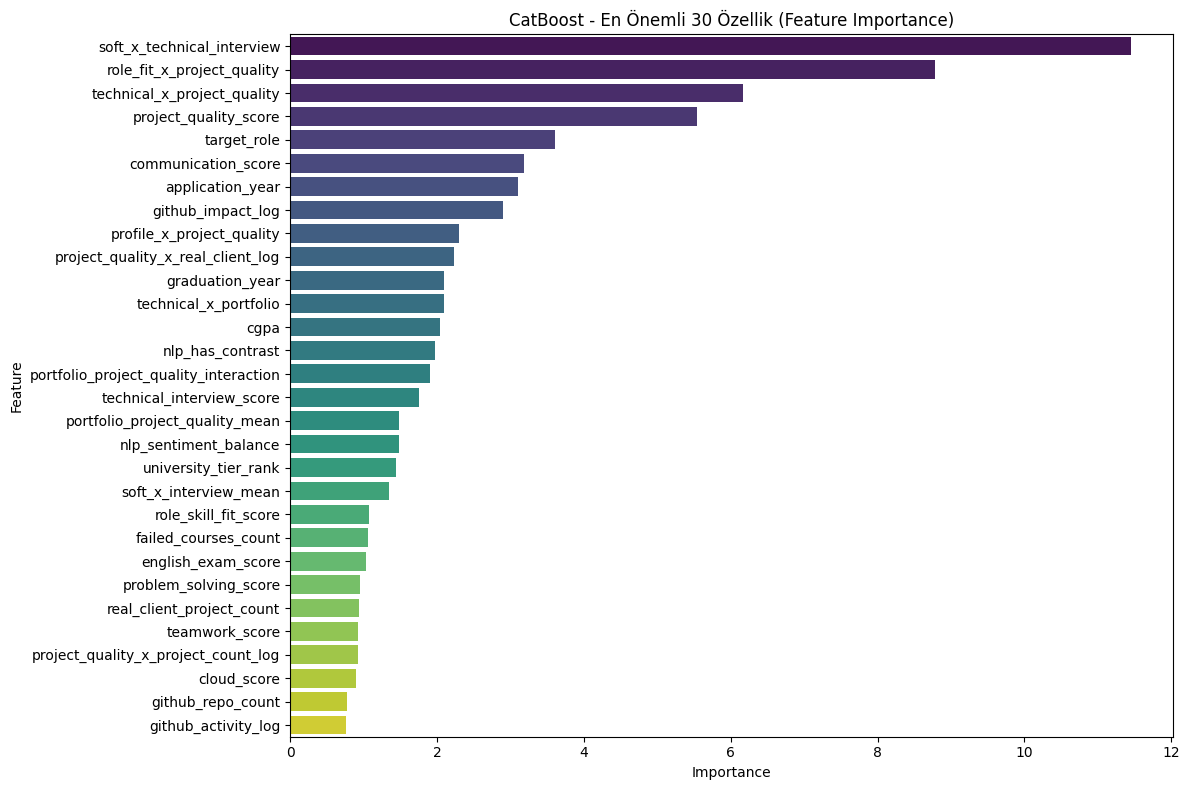


Modelin HİÇ kullanmadığı özellik sayısı: 4
Örnek gereksiz özellikler: ['english_exam_score_was_missing', 'linkedin_profile_score_was_missing', 'hr_interview_score_was_missing', 'years_since_graduation']


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor

# Hızlı bir analiz için tek bir CatBoost modeli eğitiyoruz
print("Özellik analizi için model eğitiliyor...")
analysis_model = CatBoostRegressor(
    iterations=500, # Analiz için 500 yeterli
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=42
)

analysis_model.fit(X, y, cat_features=cat_feature_indices)

# Özellik önem (Feature Importance) değerlerini alıyoruz
feature_importance = analysis_model.get_feature_importance()
fi_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': feature_importance
})

# Büyükten küçüğe sıralayalım
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Görselleştirme (İlk 30 Özellik)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(30), palette='viridis')
plt.title('CatBoost - En Önemli 30 Özellik (Feature Importance)')
plt.tight_layout()
plt.show()

# Hiçbir işe yaramayan (Önemi 0 olan) özelliklerin sayısı
zero_imp = fi_df[fi_df['Importance'] == 0]
print(f"\nModelin HİÇ kullanmadığı özellik sayısı: {len(zero_imp)}")
if len(zero_imp) > 0:
    print("Örnek gereksiz özellikler:", zero_imp['Feature'].head(5).tolist())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Us

AttributeError: _ARRAY_API not found

SHAP değerleri hesaplanıyor (Bu işlem 1-2 dakika sürebilir)...


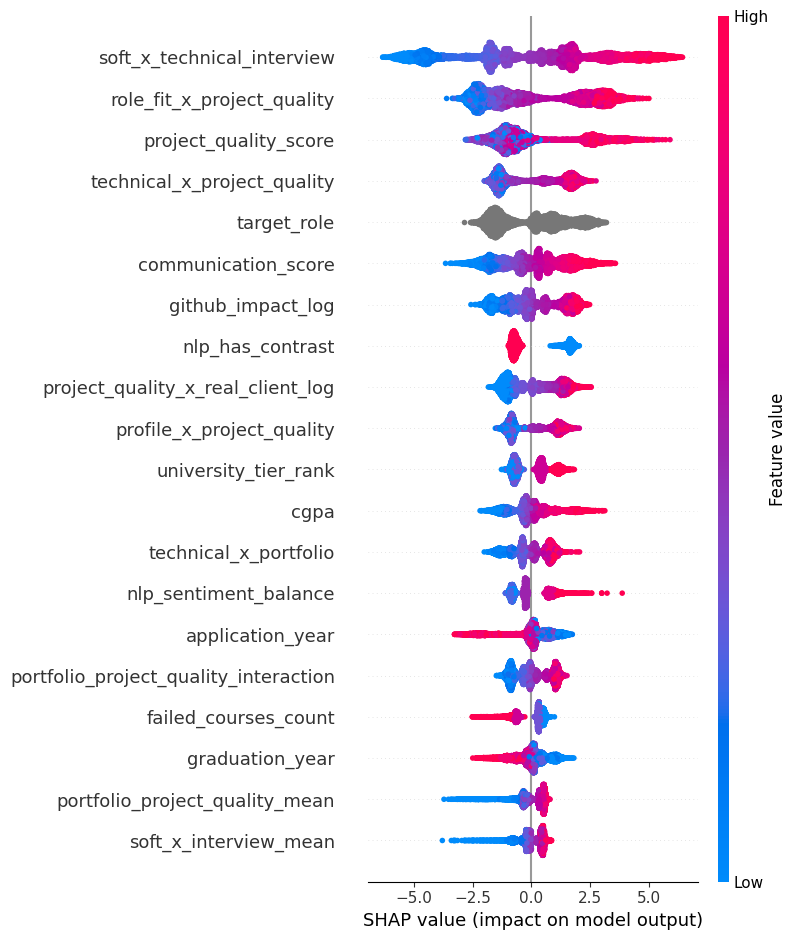

In [24]:
import shap

print("SHAP değerleri hesaplanıyor (Bu işlem 1-2 dakika sürebilir)...")
# Ağaç modelleri için SHAP Explainer
explainer = shap.TreeExplainer(analysis_model)
shap_values = explainer.shap_values(X)

# SHAP Özet Grafiği (Summary Plot)
shap.summary_plot(shap_values, X, max_display=20)

In [26]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 1. GEREKSİZ ÖZELLİKLERİ BELİRLEME (Importance değeri 0.01'den küçük olanlar çöpe)
# 'fi_df' bir önceki adımda oluşturduğumuz Feature Importance tablosu
useless_features = fi_df[fi_df['Importance'] < 0.01]['Feature'].tolist()

print(f"🗑️ Silinecek Gürültülü Özellik Sayısı: {len(useless_features)}")
print("Silinenler:", useless_features)

# 2. VERİ SETİNİ BUDAMA (Temizleme)
X_clean = X.drop(columns=useless_features, errors='ignore')
X_test_clean = X_test.drop(columns=useless_features, errors='ignore')

# Kategorik indeks listesini yeni temizlenmiş veriye göre güncelliyoruz
cat_cols_clean = [c for c in cat_cols if c in X_clean.columns]
cat_feature_indices_clean = [X_clean.columns.get_loc(c) for c in cat_cols_clean]

print(f"✨ Temizlenmiş Yeni Eğitim Seti Boyutu: {X_clean.shape}")
print("-" * 50)

# 3. OPTUNA İLE TEMİZ VERİ ÜZERİNDE NİHAİ ARAMA
def objective(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 1200, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-1, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 64, 255),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": False
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    # sklearn.cross_val_score yerine manuel ve daha güvenli döngü kuruyoruz
    for train_idx, valid_idx in kf.split(X_clean):
        X_tr, X_val = X_clean.iloc[train_idx], X_clean.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        model = CatBoostRegressor(**param)
        
        # early_stopping_rounds sayesinde model gereksiz yere binlerce ağaç kurmaz, hızlanır
        model.fit(X_tr, y_tr, 
                  cat_features=cat_feature_indices_clean, 
                  eval_set=(X_val, y_val), 
                  early_stopping_rounds=100, 
                  verbose=False)
        
        val_preds = model.predict(X_val)
        rmse = mean_squared_error(y_val, val_preds) ** 0.5
        cv_scores.append(rmse)
    
    return np.mean(cv_scores)

print("🚀 Temizlenmiş Veri ile Optuna Optimizasyonu Başlıyor...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)  # Süreyi kısaltmak için 30 deneme yeterli

print("-" * 50)
print(f"🏆 TEMİZ VERİ İLE EN İYİ OOF RMSE: {study.best_value:.4f}")
print("🎯 En İyi Parametreler:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

print("-" * 50)
print(f"🏆 TEMİZ VERİ İLE EN İYİ OOF RMSE: {study.best_value:.4f}")
print("🎯 En İyi Parametreler:", study.best_params)

[I 2026-06-13 15:24:43,673] A new study created in memory with name: no-name-d8ec3a1e-90e3-4bde-839a-76265ec14e68


🗑️ Silinecek Gürültülü Özellik Sayısı: 4
Silinenler: ['english_exam_score_was_missing', 'linkedin_profile_score_was_missing', 'hr_interview_score_was_missing', 'years_since_graduation']
✨ Temizlenmiş Yeni Eğitim Seti Boyutu: (10000, 111)
--------------------------------------------------
🚀 Temizlenmiş Veri ile Optuna Optimizasyonu Başlıyor...


[I 2026-06-13 15:26:43,228] Trial 0 finished with value: 8.911782505603924 and parameters: {'iterations': 1667, 'learning_rate': 0.07851535891846895, 'depth': 4, 'l2_leaf_reg': 0.15026651522815493, 'random_strength': 0.03568298406399259, 'bagging_temperature': 0.6947725625316827, 'border_count': 192}. Best is trial 0 with value: 8.911782505603924.
[W 2026-06-13 15:29:06,585] Trial 1 failed with parameters: {'iterations': 1989, 'learning_rate': 0.06310107533993624, 'depth': 8, 'l2_leaf_reg': 1.3901613922691127, 'random_strength': 0.05924072656881809, 'bagging_temperature': 0.24360222565295298, 'border_count': 80} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\busra\AppData\Local\Temp\ipykernel_23804\560853183.py", line 51, in objective
    model.fit

KeyboardInterrupt: 

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. NİHAİ VERİ HAZIRLIĞI
# Hedef, ID ve ham metin kolonlarını atıyoruz. 
# Eğer önceden useless_features (çöp kolonlar) tanımladıysak onları da siliyoruz.
drop_cols = [TARGET, ID_COL, 'mentor_feedback_text']
if 'useless_features' in locals() or 'useless_features' in globals():
    drop_cols.extend(useless_features)

X_final = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns])
y_final = train_fe[TARGET]

X_test_final = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns])
X_test_final = X_test_final.reindex(columns=X_final.columns) # Sıralamayı garantiye al

# Kategorik kolonların güncellenmesi
cat_cols_final = X_final.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols_final:
    X_final[col] = X_final[col].fillna("Unknown").astype(str)
    X_test_final[col] = X_test_final[col].fillna("Unknown").astype(str)
cat_feature_indices_final = [X_final.columns.get_loc(c) for c in cat_cols_final]

print(f"✨ Nihai Eğitim Seti Boyutu: {X_final.shape}")
print("-" * 50)

# 2. OPTUNA İLE NİHAİ HİPERPARAMETRE ARAMASI (Hatasız K-Fold Döngüsü)
def objective(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 1200, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-1, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 64, 255),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": False
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, valid_idx in kf.split(X_final):
        X_tr, X_val = X_final.iloc[train_idx], X_final.iloc[valid_idx]
        y_tr, y_val = y_final.iloc[train_idx], y_final.iloc[valid_idx]
        
        model = CatBoostRegressor(**param)
        
        # early_stopping_rounds ile model gereksiz yere uzamaz, zamandan tasarruf edilir
        model.fit(X_tr, y_tr, 
                  cat_features=cat_feature_indices_final, 
                  eval_set=(X_val, y_val), 
                  early_stopping_rounds=100, 
                  verbose=False)
        
        val_preds = model.predict(X_val)
        rmse = mean_squared_error(y_val, val_preds) ** 0.5
        cv_scores.append(rmse)
    
    return np.mean(cv_scores)

print("🚀 Nihai Veri Seti ile Optuna Optimizasyonu Başlıyor...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)  # 30 deneme idealdir

print("-" * 50)
print(f"🏆 NİHAİ MODEL OOF RMSE: {study.best_value:.4f}")
print("🎯 En İyi Parametreler:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-06-13 15:56:24,172] A new study created in memory with name: no-name-4ca296bb-7a78-4e17-a976-fbcb2bd4803c


✨ Nihai Eğitim Seti Boyutu: (10000, 105)
--------------------------------------------------
🚀 Nihai Veri Seti ile Optuna Optimizasyonu Başlıyor...


[I 2026-06-13 16:02:41,168] Trial 0 finished with value: 8.74386734791533 and parameters: {'iterations': 2179, 'learning_rate': 0.031222976569598354, 'depth': 5, 'l2_leaf_reg': 1.620542149437168, 'random_strength': 0.05775084862971827, 'bagging_temperature': 0.7705415329870753, 'border_count': 69}. Best is trial 0 with value: 8.74386734791533.
[I 2026-06-13 16:10:26,155] Trial 1 finished with value: 8.861705479769233 and parameters: {'iterations': 1394, 'learning_rate': 0.010490932881244003, 'depth': 5, 'l2_leaf_reg': 4.726954768675255, 'random_strength': 4.552121343110736, 'bagging_temperature': 0.6419882717659958, 'border_count': 99}. Best is trial 0 with value: 8.74386734791533.
